# 14 — Gesture triplet-loss embedder (v3)

Changes from v1/v2, made after reviewing that run's output:

1. **Fixed a survivorship confound in evaluation.** The AUC-vs-k curve
   previously let the probe-identity set shrink as k grew (12 identities at
   k=1, down to 8 at k=20, since low-volume people can't supply k consecutive
   probe windows) -- the exact same confound already caught and fixed in
   `evaluate_trust_windows.py`, which this notebook had not inherited. Fixed
   here the same way: a fixed identity set (everyone with enough probe
   windows for the LARGEST k) is evaluated at every k, alongside the
   all-available-identities view, so the two can be told apart. Per-identity
   AUC is now also recorded at every k, which the previous export was
   missing entirely.
2. **Added permutation feature importance** (Section 9). No retraining
   needed -- computed on the already-trained primary model by shuffling one
   feature at a time across probe windows and measuring the AUC drop.
3. **Much faster.** The previous version trained 7 full models from scratch
   (1 primary + 3 seeds + 3 shuffled-label controls), each running as many
   batches per epoch as the largest identity's window count allowed --
   unbounded, and growing every time more data is collected. Capped batches
   per epoch (Section 3) and added checkpointing for the primary model
   (Section 4) so re-running the notebook after a fresh `data/` pull does
   not redo work unless the underlying data actually changed.

See the very last markdown cell for how to avoid the wait entirely on
smaller edits.


In [ ]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

# Stops the inline backend auto-closing each figure right after display --
# without this, plt.get_fignums() finds nothing by the time Section 10 runs
# (this bit an earlier version: all 6 plots rendered fine in the notebook,
# but the export cell silently saved zero of them).
%config InlineBackend.close_figures = False

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
gesture_path = find(str(MOD_DIR / 'gesture_windows.parquet'), 'gesture_windows.parquet',
                     '/mnt/user-data/uploads/gesture_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv',
                    '/mnt/user-data/uploads/identity_splits.csv')

OUT_DIR = Path(find('data/processed/gesture_embedder', '../data/processed/gesture_embedder', '.'))
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

df = pd.read_parquet(gesture_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
print(f"gesture windows: {df.shape}, sessions matched to splits: {df['sessionId'].nunique()}")
print(df.groupby('role').size())


Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/modelling/gesture_embedder
gesture windows: (3054, 114), sessions matched to splits: 86
role
enrol     545
probe     350
train    2159
dtype: int64


## 1. Feature preparation

In [2]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
print(f"X_all: {X_all.shape}")

# A short hash of the inputs that determine training outcome (data + feature
# list + hyperparameters, set below), used by the checkpoint cache in
# Section 4 to tell "nothing changed, safe to reuse" from "something did".
def data_fingerprint():
    h = hashlib.sha256()
    h.update(X_all.tobytes()); h.update(str(sorted(feats)).encode())
    h.update(role_all.tobytes() if role_all.dtype.kind in 'iuf' else str(list(role_all)).encode())
    return h.hexdigest()[:16]


61 features used
X_all: (3054, 61)


## 2. Batch composition check

participantId
pCURDWC     22
pG2C8BC     26
pEAB9GS     31
pCTJ44P     35
pUNKH7L     45
pEZVKTS     56
pZMC82M     56
pA6XL23     80
pWJGKPK     80
pAFQRTM     91
pNDG8LJ    159
pG5G4MS    200
p3YDMHG    300
pH3S4X4    470
p95MPVX    508


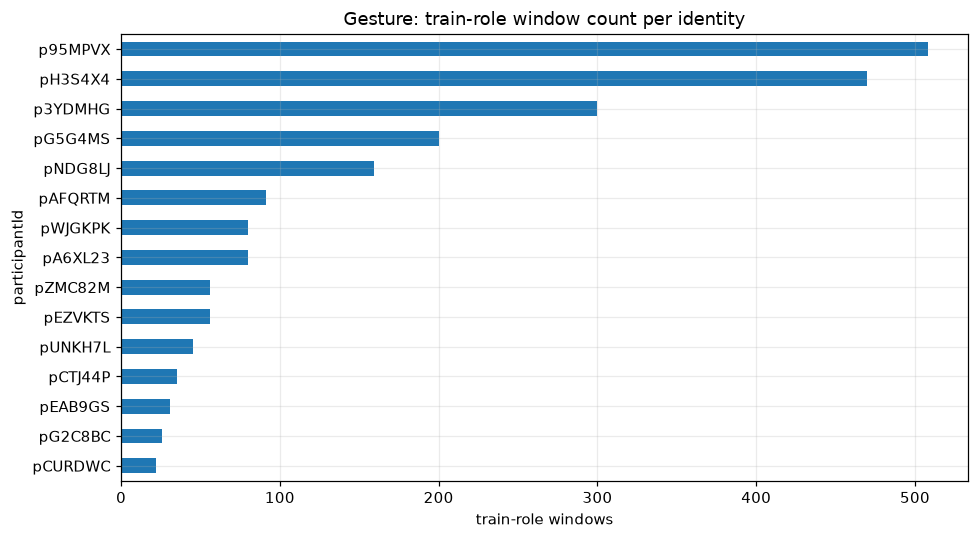


15 identities have train-role data, minimum 22 windows.


In [3]:
train_counts = df[df['role']=='train'].groupby('participantId').size().sort_values()
print(train_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
train_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('train-role windows'); ax.set_title('Gesture: train-role window count per identity')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_train_windows_per_identity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{len(train_counts)} identities have train-role data, minimum {train_counts.min()} windows.")


## 3. Batch sampler and model

Architecture unchanged from v1/v2 (P1's 256-128-32 MLP, dropout 0.10,
L2-normalised output, batch-all triplet loss, margin 0.20).

**Speed fix**: `BalancedIdentityBatchSampler` previously sized one epoch off
the TOTAL window count across all identities (`sum(len(v))`), so as
high-volume identities accumulate more sessions over time, every epoch gets
slower even though the small-cohort sampling logic doesn't actually need
more batches to see the data -- each batch is only 2 identities x 4 windows
regardless of how much data exists. Capped at `MAX_BATCHES_PER_EPOCH`
instead. This is the main reason the previous version took ~10 minutes for
what is architecturally a very small model.

In [4]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_BATCHES_PER_EPOCH = 150   # was unbounded (grew with dataset size); capped
                              # here since sampling is random each epoch
                              # regardless, so more batches beyond this
                              # point buys more compute, not more coverage

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity,
                 max_batches=MAX_BATCHES_PER_EPOCH, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        natural = max(1, sum(len(v) for v in self.by_identity.values()) // (self.k * self.m))
        self.n_batches = min(natural, max_batches)

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m, replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask, diff = same & ~eye, ~same

    losses = []
    for a in range(len(embeddings)):
        pos_d, neg_d = dist[a][pos_mask[a]], dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True), 0.0
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))

print(f"input dim {len(feats)}, embedding dim {EMBED_DIM}, "
      f"up to {MAX_BATCHES_PER_EPOCH} batches/epoch (was unbounded)")


input dim 61, embedding dim 32, up to 150 batches/epoch (was unbounded)


## 4. Training, with a checkpoint cache

`FORCE_RETRAIN = False` by default: if a checkpoint exists whose data
fingerprint matches the current `X_all`/features/roles, it's loaded instead
of retraining. Set `FORCE_RETRAIN = True` after a genuine change (new data,
different hyperparameters) to force a fresh run. This is what makes
"Restart & Run All" cheap on repeat runs where nothing upstream changed --
see the final markdown cell for the rest of the workflow advice.

In [5]:
FORCE_RETRAIN = False

def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]
    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)
    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  active_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

fp = data_fingerprint()
ckpt_path = CKPT_DIR / f'primary_seed42_{fp}.pt'
if ckpt_path.exists() and not FORCE_RETRAIN:
    print(f"Loading cached model (fingerprint {fp}) -- set FORCE_RETRAIN=True to retrain.")
    ckpt = torch.load(ckpt_path, weights_only=False)
    model = Embedder(len(feats), EMBED_DIM)
    model.load_state_dict(ckpt['state_dict'])
    history = ckpt['history']
else:
    print("Training real-label model (seed=42)...")
    model, history = train_embedder(X_all, y_all, role_all, seed=42)
    torch.save({'state_dict': model.state_dict(), 'history': history}, ckpt_path)
    print(f"Cached to {ckpt_path.name}")


Loading cached model (fingerprint 04e56bc6e42c35d2) -- set FORCE_RETRAIN=True to retrain.


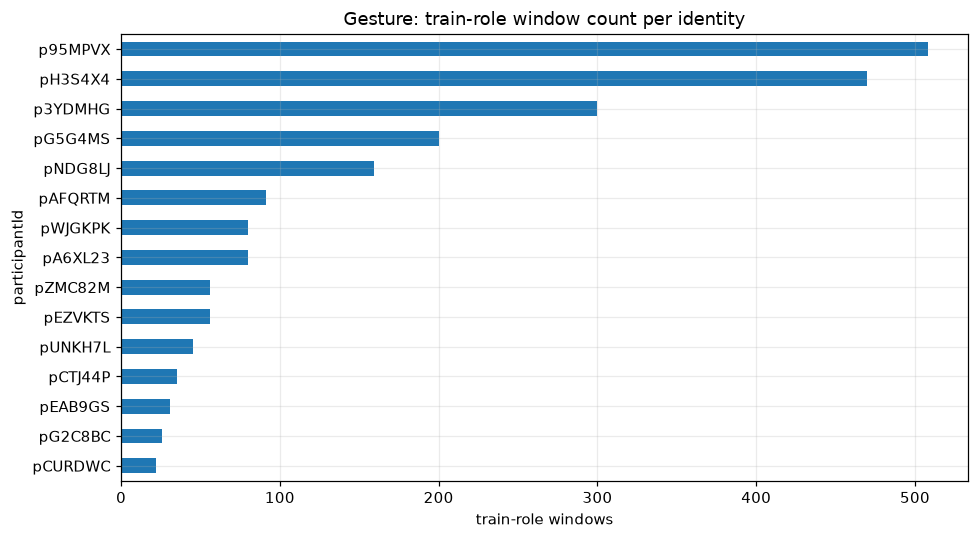

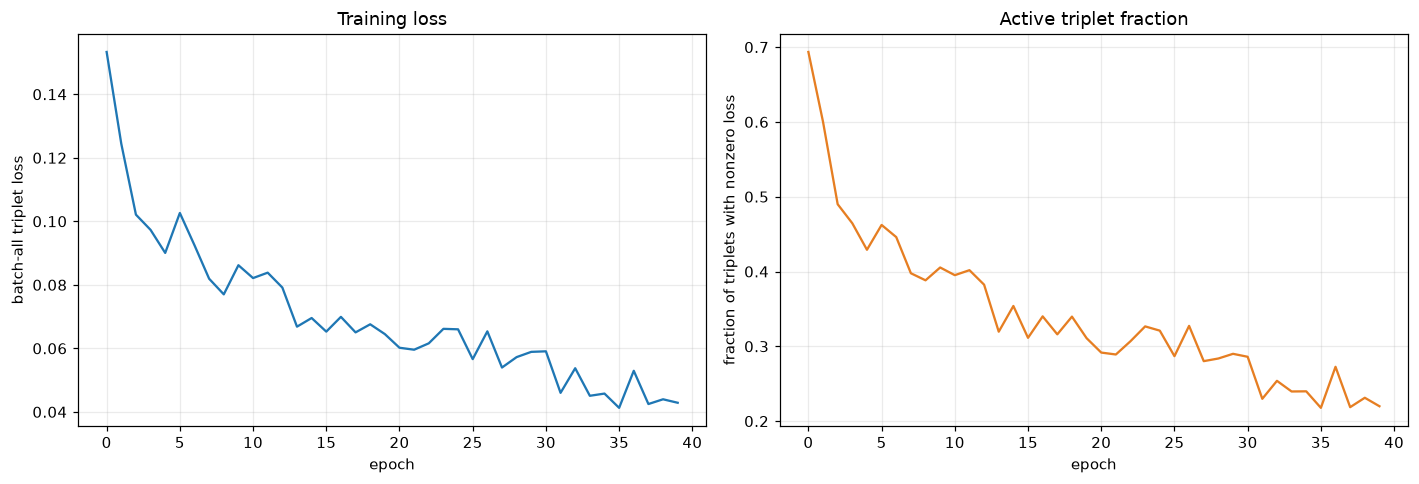

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('batch-all triplet loss'); axes[0].set_title('Training loss')
axes[1].plot(history['epoch'], history['active_frac'], color='#e67e22')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('fraction of triplets with nonzero loss')
axes[1].set_title('Active triplet fraction')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Evaluation -- fixed identity set

The core fix from v2. `evaluate_model` now returns BOTH the all-available
view (identity set shrinks as k grows -- kept for reference, not for
conclusions) and a fixed-identity-set view restricted to identities with
enough probe windows for the LARGEST k, evaluated identically at every k
so the curve is like-for-like across k. Per-identity AUC is now recorded
too, which the previous export didn't have at all.

In [7]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def embed(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()

def score_probe_windows(E, y, df_meta, role, k_values):
    """Long-form scored rows: one per (k, probe_pid, candidate, trust-window
    instance). trust_id lets cohort normalisation and per-identity breakdown
    both work off the same table."""
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0) for pid in np.unique(y[enrol_mask])}
    rows = []
    for pid in np.unique(y[probe_mask]):
        idx = np.where(probe_mask & (y == pid))[0]
        order = np.argsort(df_meta.loc[idx, 'window_start_s'].values)
        Ep = E[idx[order]]
        for k in k_values:
            if len(Ep) < k: continue
            for i in range(len(Ep) - k + 1):
                agg = Ep[i:i+k].mean(axis=0)
                for cand, ref in refs.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref)),
                                 'trust_id': f'{pid}|{i}|{k}'})
    return pd.DataFrame(rows), refs

def summarise(scored, fixed_identities=None, label=''):
    """Cohort-normalised AUC per k (and per identity), optionally
    restricted to a fixed identity set."""
    if fixed_identities is not None:
        scored = scored[scored['pid'].isin(fixed_identities)]
    per_k, per_identity = [], []
    for k, g in scored.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        per_k.append({'k': k, 'identity_set': label, 'n_probe_identities': g['pid'].nunique(),
                       'n_trust_windows': g['trust_id'].nunique(),
                       **compute_metrics(g['genuine'], -g['z'])})
        for pid, gp in g.groupby('pid'):
            if gp['genuine'].nunique() < 2: continue
            per_identity.append({'k': k, 'identity_set': label, 'participantId': pid,
                                  'auc': roc_auc_score(gp['genuine'], -gp['z']),
                                  'n_comparisons': len(gp)})
    return pd.DataFrame(per_k), pd.DataFrame(per_identity)

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
E_all = embed(model, X_all)
df_idx = df.reset_index(drop=True)
scored, refs = score_probe_windows(E_all, y_all, df_idx, role_all, k_values)
print(f"{len(refs)} reference identities, {len(scored)} scored rows")

res_all, per_id_all = summarise(scored, fixed_identities=None, label='all_available')

max_k = max(k_values)
probe_counts = df_idx[df_idx['role']=='probe'].groupby('participantId').size()
fixed_identities = set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())
print(f"{len(fixed_identities)} identities have >= {max_k} probe windows: {sorted(fixed_identities)}")

if len(fixed_identities) >= 2:
    res_fixed, per_id_fixed = summarise(scored, fixed_identities=fixed_identities, label='fixed_across_k')
else:
    print("WARNING: fewer than 2 identities qualify for the fixed set -- reporting all_available only.")
    res_fixed, per_id_fixed = res_all.copy(), per_id_all.copy()

res_df = pd.concat([res_all, res_fixed], ignore_index=True)
per_id_df = pd.concat([per_id_all, per_id_fixed], ignore_index=True)
print()
print(res_df[res_df['identity_set']=='fixed_across_k']
      [['k','n_probe_identities','auc','eer']].to_string(index=False, float_format=lambda v:f'{v:.3f}'))


12 reference identities, 25668 scored rows
8 identities have >= 20 probe windows: ['p3M6E7Z', 'p3YDMHG', 'p95MPVX', 'pAFQRTM', 'pH3S4X4', 'pNDG8LJ', 'pUNKH7L', 'pWS9VTN']

 k  n_probe_identities   auc   eer
 1                   8 0.774 0.307
 2                   8 0.796 0.279
 3                   8 0.814 0.275
 5                   8 0.837 0.239
 8                   8 0.859 0.208
10                   8 0.869 0.197
15                   8 0.892 0.151
20                   8 0.920 0.125


## 6. Trained embedder vs raw-distance baseline

Both identity-set views plotted, so the effect of the fix in Section 5 is
visible directly rather than asserted.

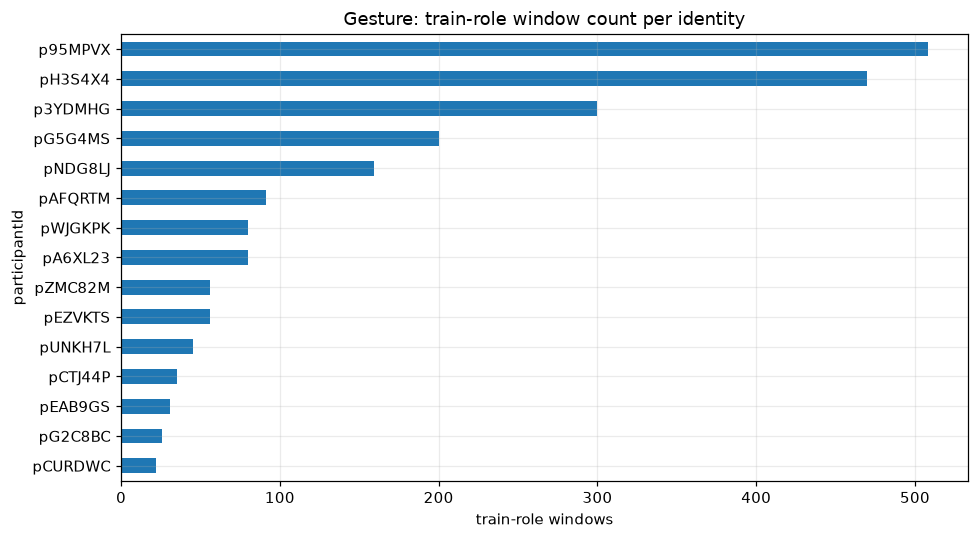

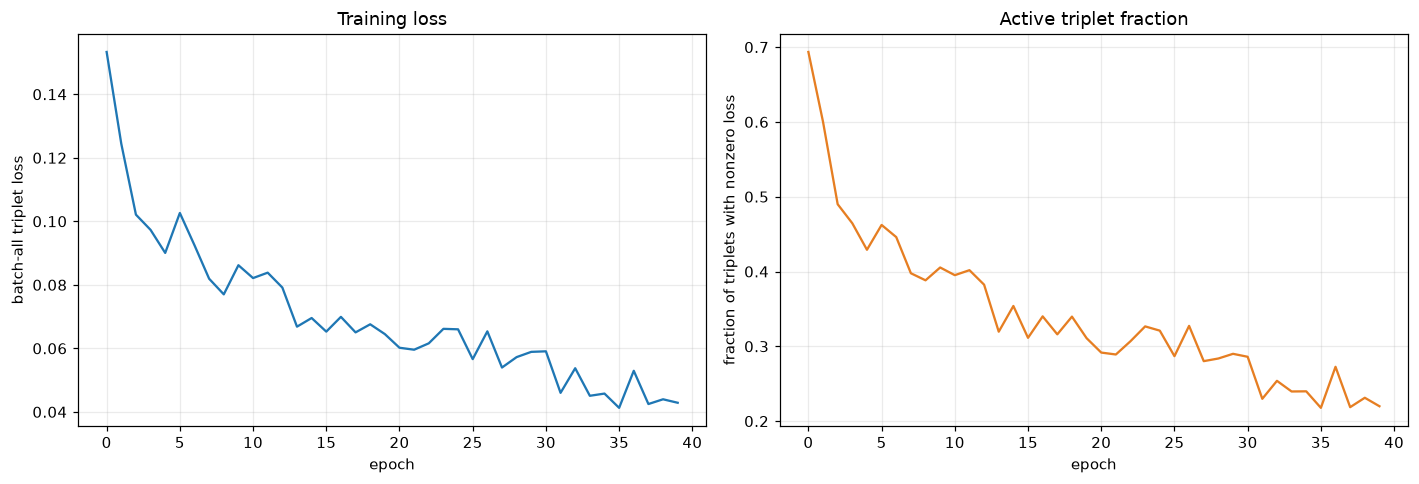

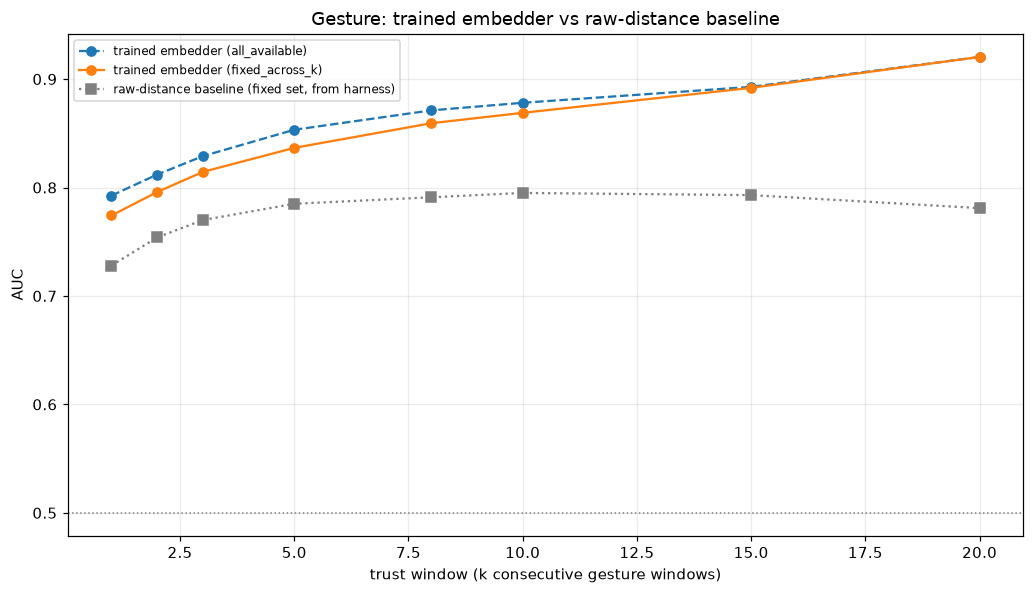

AUC at k=20, all_available minus fixed_across_k: +0.000 (positive means the earlier, unfixed curve was inflated by identity dropout)


In [8]:
BASELINE_AUC = {1: 0.728, 2: 0.754, 3: 0.770, 5: 0.785, 8: 0.791, 10: 0.795, 15: 0.793, 20: 0.781}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, style in [('all_available', '--'), ('fixed_across_k', '-')]:
    sub = res_df[res_df['identity_set']==label].sort_values('k')
    ax.plot(sub['k'], sub['auc'], marker='o', ls=style, label=f'trained embedder ({label})')
bl_k = [k for k in k_values if k in BASELINE_AUC]
ax.plot(bl_k, [BASELINE_AUC[k] for k in bl_k], marker='s', ls=':', color='gray',
        label='raw-distance baseline (fixed set, from harness)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('trust window (k consecutive gesture windows)'); ax.set_ylabel('AUC')
ax.set_title('Gesture: trained embedder vs raw-distance baseline')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '03_embedder_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

drop_at_20 = res_df[(res_df['identity_set']=='all_available')&(res_df['k']==20)]['auc'].iloc[0] - \
             res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)]['auc'].iloc[0]
print(f"AUC at k=20, all_available minus fixed_across_k: {drop_at_20:+.3f} "
      f"(positive means the earlier, unfixed curve was inflated by identity dropout)")


## 7. Multi-seed stability (fixed identity set)

In [9]:
SEEDS = [7, 13, 42]
seed_results = []
for seed in SEEDS:
    print(f"seed {seed}...")
    ckpt_s = CKPT_DIR / f'seed{seed}_{fp}.pt'
    if ckpt_s.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_s, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_all, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_s)
    Es = embed(m, X_all)
    sc, _ = score_probe_windows(Es, y_all, df_idx, role_all, [1, 10, 20])
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    seed_results.append(rk)

seed_df = pd.concat(seed_results, ignore_index=True)
summary = seed_df.groupby('k')['auc'].agg(['mean', 'std'])
print(summary.round(3).to_string())


seed 7...
seed 13...
seed 42...
     mean    std
k               
1   0.775  0.005
10  0.869  0.008
20  0.908  0.013


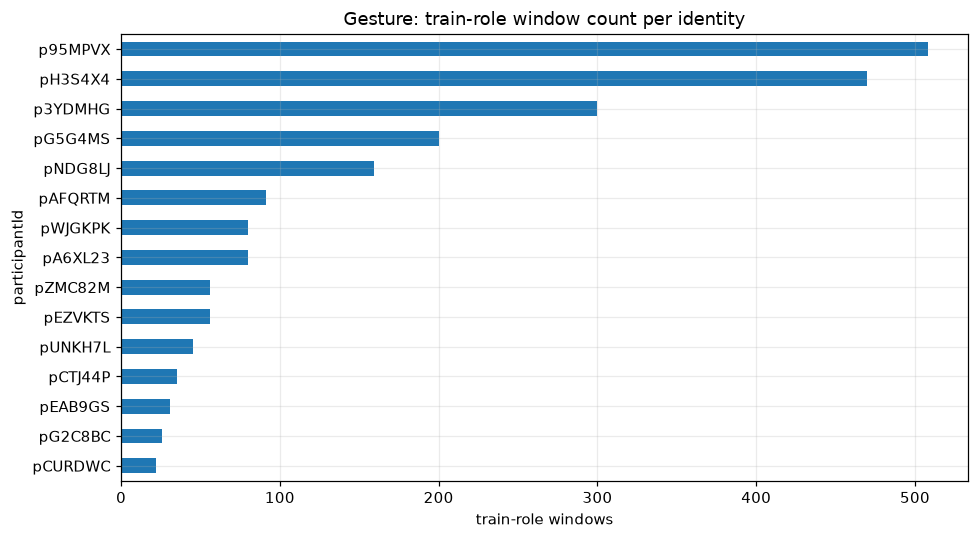

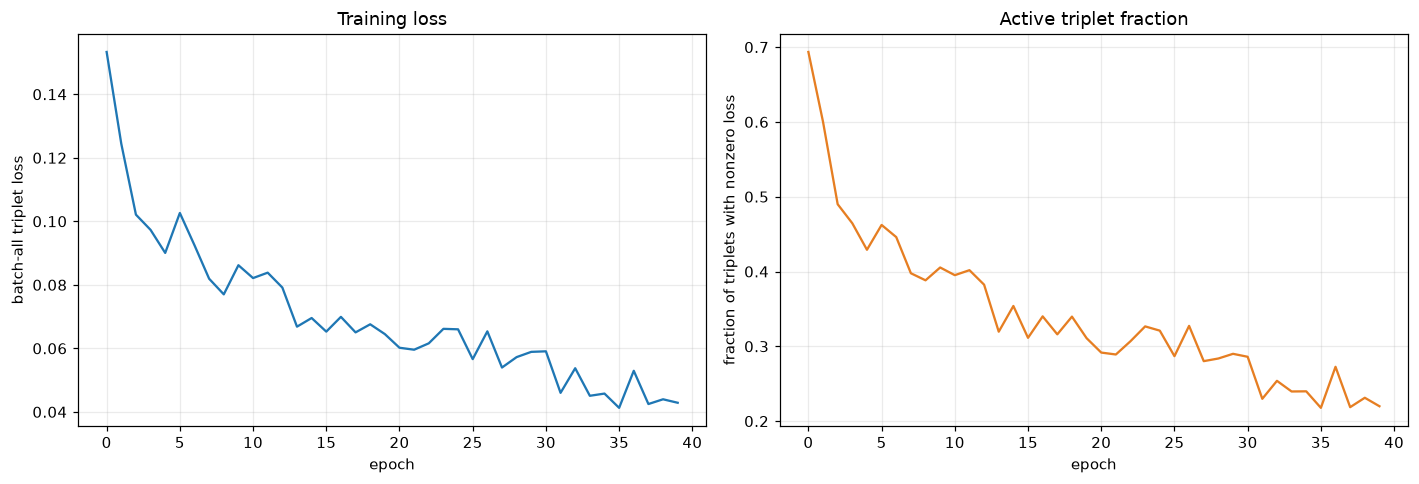

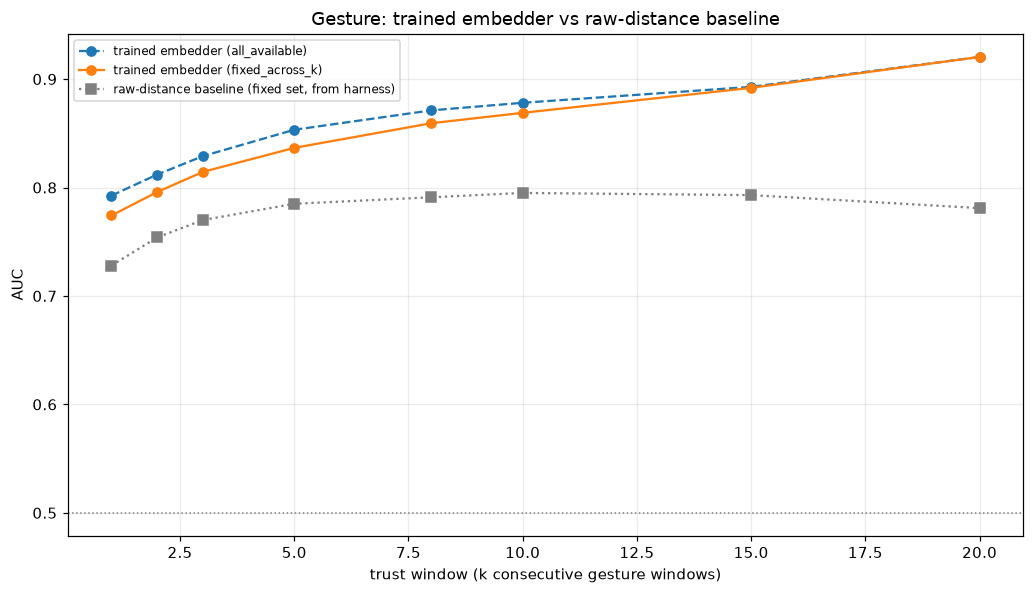

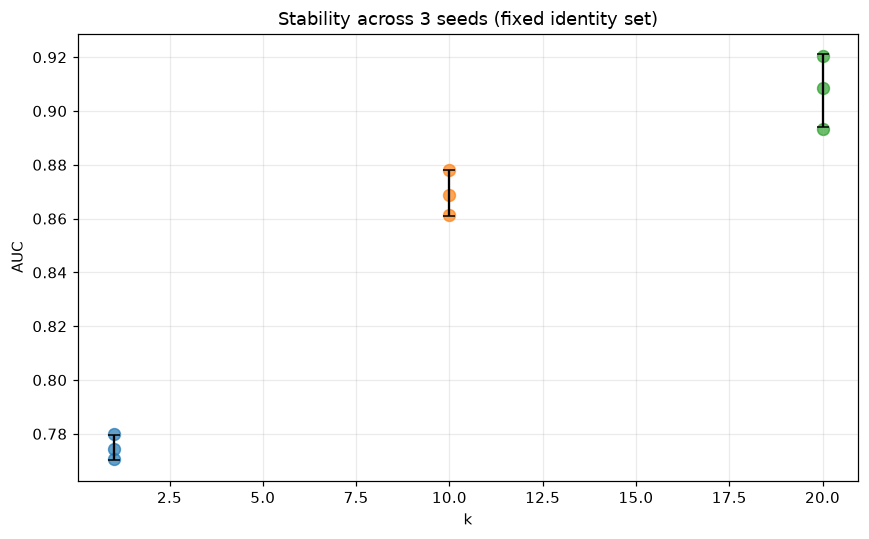

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in seed_df['k'].unique():
    vals = seed_df[seed_df['k']==k]['auc']
    ax.scatter([k]*len(vals), vals, alpha=0.7, s=60)
ax.errorbar(summary.index, summary['mean'], yerr=summary['std'], fmt='none', color='k', capsize=4)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title(f'Stability across {len(SEEDS)} seeds (fixed identity set)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '04_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Negative control -- trained model, fixed identity set

In [11]:
def shuffle_labels(y, df_meta, seed):
    rng = np.random.default_rng(seed)
    sess_pid = df_meta.groupby('sessionId')['participantId'].first()
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return df_meta['sessionId'].map(mapping).values

control_results = []
for seed in [0, 1, 2]:
    y_shuf = shuffle_labels(y_all, df_idx, seed)
    ckpt_c = CKPT_DIR / f'control{seed}_{fp}.pt'
    if ckpt_c.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_c, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_shuf, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_c)
    Ec = embed(m, X_all)
    sc, _ = score_probe_windows(Ec, y_shuf, df_idx, role_all, [1, 10, 20])
    # fixed_identities was computed on REAL labels; under shuffled labels the
    # same session-level identity assignment still applies (labels are
    # shuffled at session level), so the same set is a fair restriction here.
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    control_results.append(rk)

control_df = pd.concat(control_results, ignore_index=True)
ctrl_summary = control_df.groupby('k')['auc'].agg(['mean', 'std'])
print("shuffled-label control:"); print(ctrl_summary.round(3).to_string())
compare = summary[['mean']].join(ctrl_summary[['mean']], lsuffix='_real', rsuffix='_shuffled')
compare['gap'] = compare['mean_real'] - compare['mean_shuffled']
print(); print(compare.round(3).to_string())


shuffled-label control:
     mean    std
k               
1   0.415  0.087
10  0.333  0.140
20  0.295  0.158

    mean_real  mean_shuffled    gap
k                                  
1       0.775          0.415  0.360
10      0.869          0.333  0.537
20      0.908          0.295  0.612


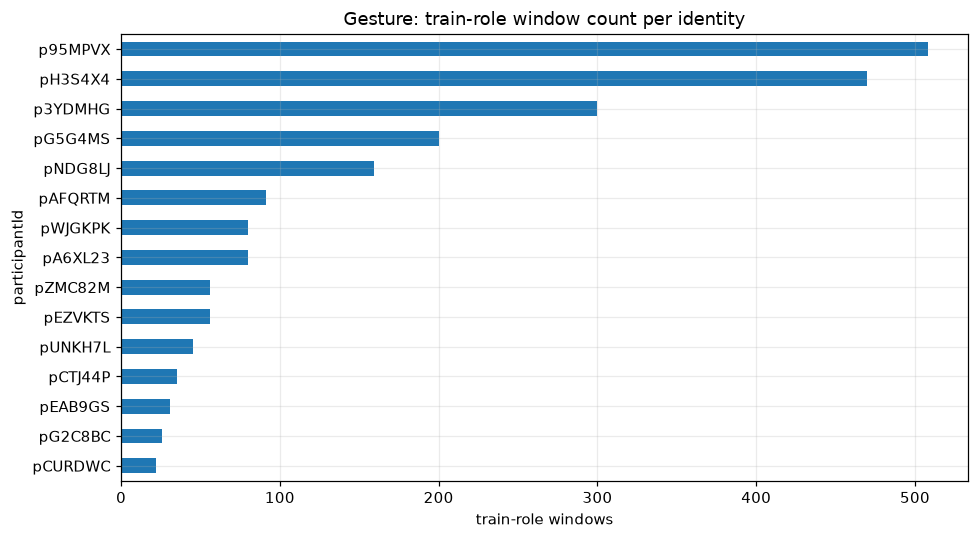

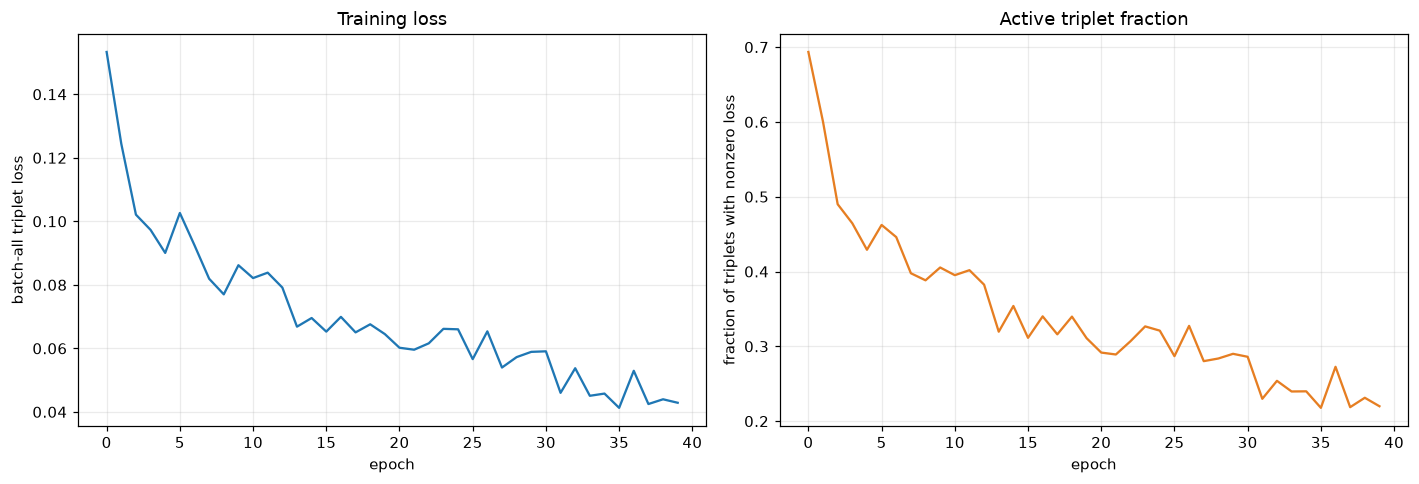

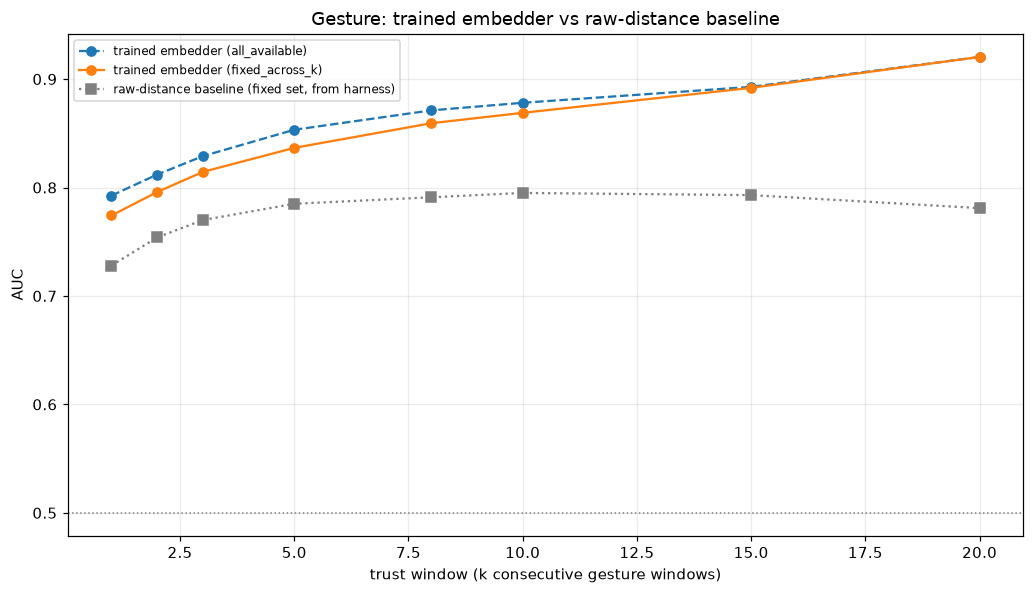

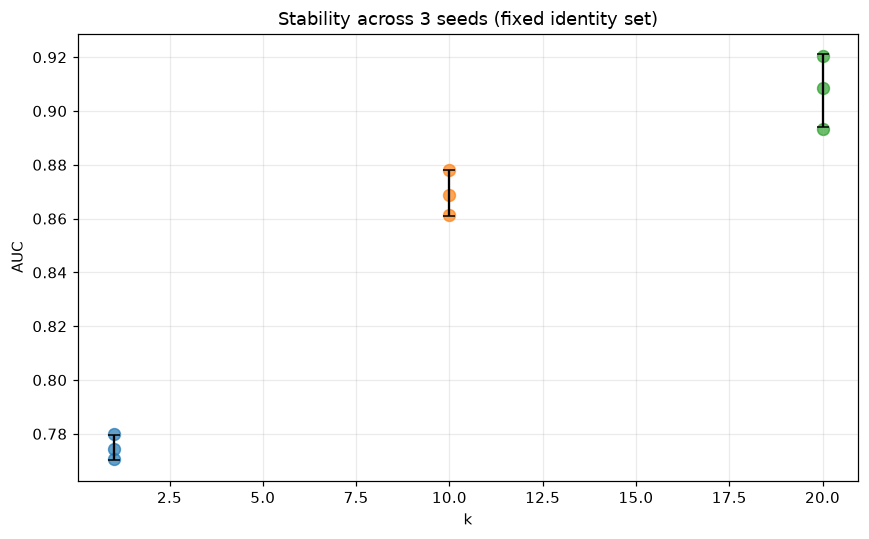

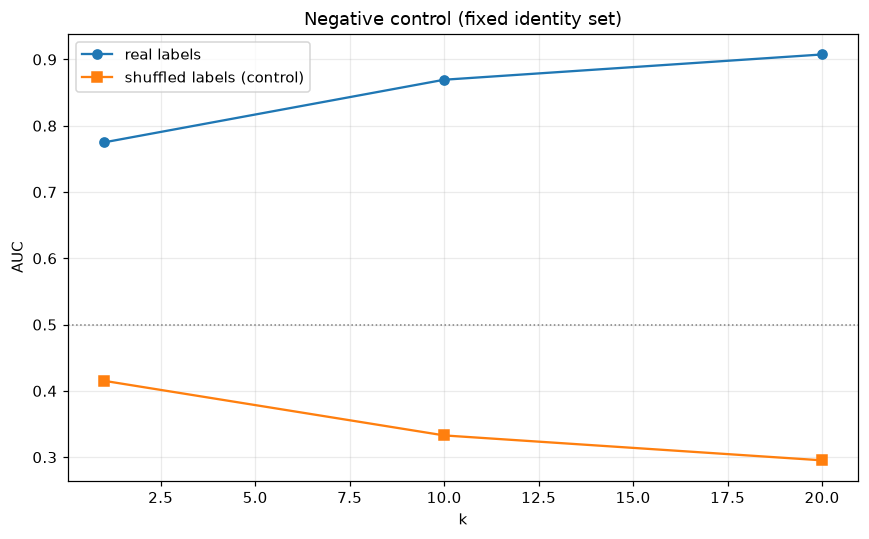

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary.index, summary['mean'], marker='o', label='real labels')
ax.plot(ctrl_summary.index, ctrl_summary['mean'], marker='s', label='shuffled labels (control)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title('Negative control (fixed identity set)')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / '05_negative_control.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Permutation feature importance

For each feature, its values are shuffled across all probe windows (breaking
whatever relationship it had to identity while leaving every other feature
intact), embeddings are recomputed with the already-trained model -- no
retraining -- and the drop in fixed-identity-set AUC at k=1 is the
importance score. Larger drop = more load-bearing. This is model-agnostic
and doesn't assume anything about the MLP's internals, unlike a
gradient-based saliency method would.

In [13]:
rng = np.random.default_rng(0)
probe_mask = role_all == 'probe'
baseline_scored, _ = score_probe_windows(E_all, y_all, df_idx, role_all, [1])
baseline_res, _ = summarise(baseline_scored, fixed_identities=fixed_identities, label='fixed_across_k')
baseline_auc = baseline_res.loc[baseline_res['k']==1, 'auc'].iloc[0]
print(f"baseline (unpermuted) AUC at k=1: {baseline_auc:.3f}")

importances = []
X_perm_base = X_all.copy()
for j, feat_name in enumerate(feats):
    X_perm = X_perm_base.copy()
    perm_idx = rng.permutation(np.where(probe_mask)[0])
    X_perm[np.where(probe_mask)[0], j] = X_perm_base[perm_idx, j]
    E_perm = embed(model, X_perm)
    sc_perm, _ = score_probe_windows(E_perm, y_all, df_idx, role_all, [1])
    res_perm, _ = summarise(sc_perm, fixed_identities=fixed_identities, label='fixed_across_k')
    perm_auc = res_perm.loc[res_perm['k']==1, 'auc'].iloc[0] if len(res_perm) else np.nan
    importances.append({'feature': feat_name, 'auc_drop': baseline_auc - perm_auc})

importance_df = pd.DataFrame(importances).sort_values('auc_drop', ascending=False)
print(importance_df.head(15).to_string(index=False, float_format=lambda v: f'{v:.4f}'))


baseline (unpermuted) AUC at k=1: 0.774
                                feature  auc_drop
  coupling_gesture_mid_phase_energy_max    0.0280
                  gesture_stroke_x0_max    0.0196
                      gesture_share_tap    0.0095
 coupling_gesture_peak_phase_energy_max    0.0067
 coupling_gesture_mid_phase_energy_mean    0.0061
                gesture_hold_tap_ms_p95    0.0060
       gesture_hold_scroll_fling_ms_max    0.0056
                   gesture_stroke_x0_cv    0.0052
                  gesture_stroke_x0_iqr    0.0049
             gesture_hold_tap_ms_median    0.0047
  gesture_scroll_fling_coast_frac_slope    0.0045
coupling_gesture_peak_phase_energy_mean    0.0041
               gesture_share_drag_swipe    0.0040
 coupling_gesture_peak_phase_energy_std    0.0037
        gesture_hold_scroll_fling_ms_cv    0.0036


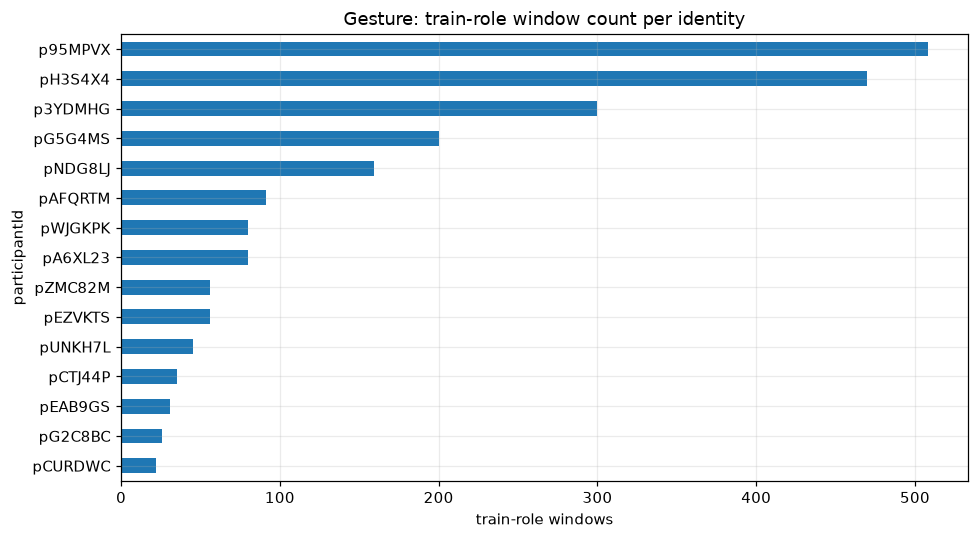

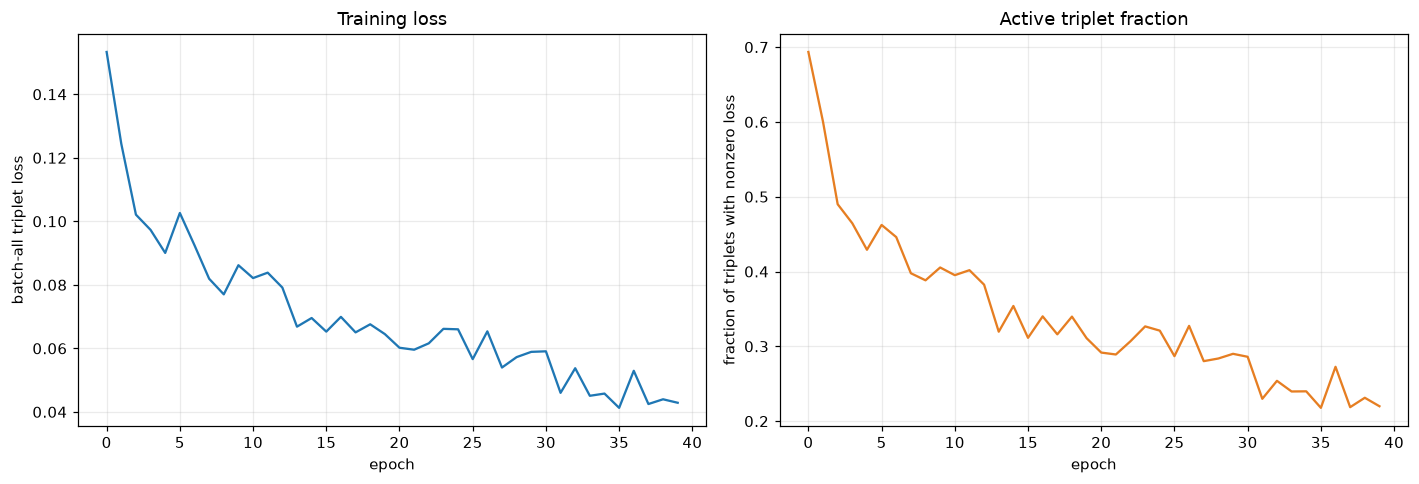

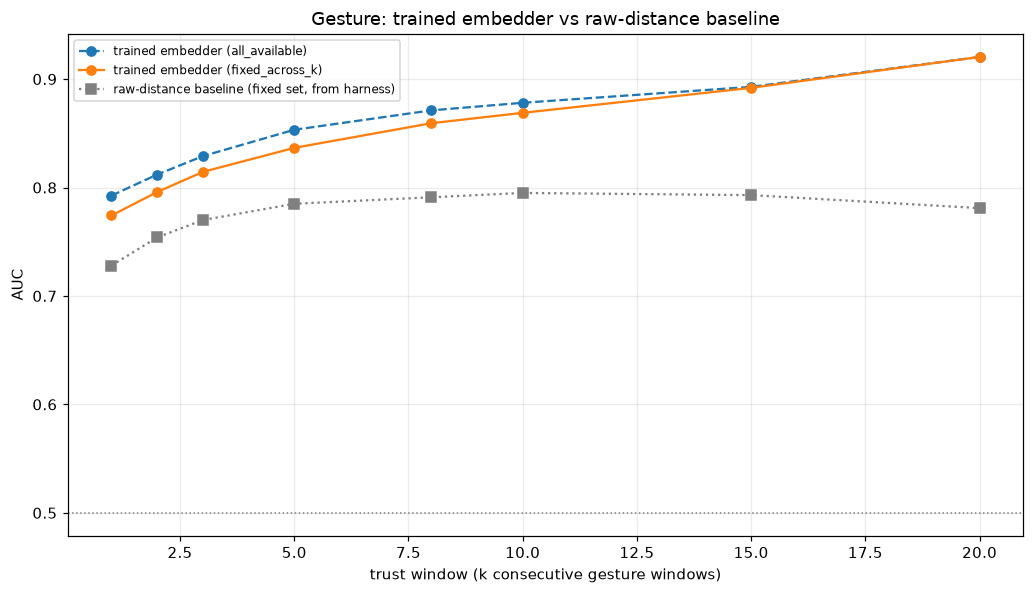

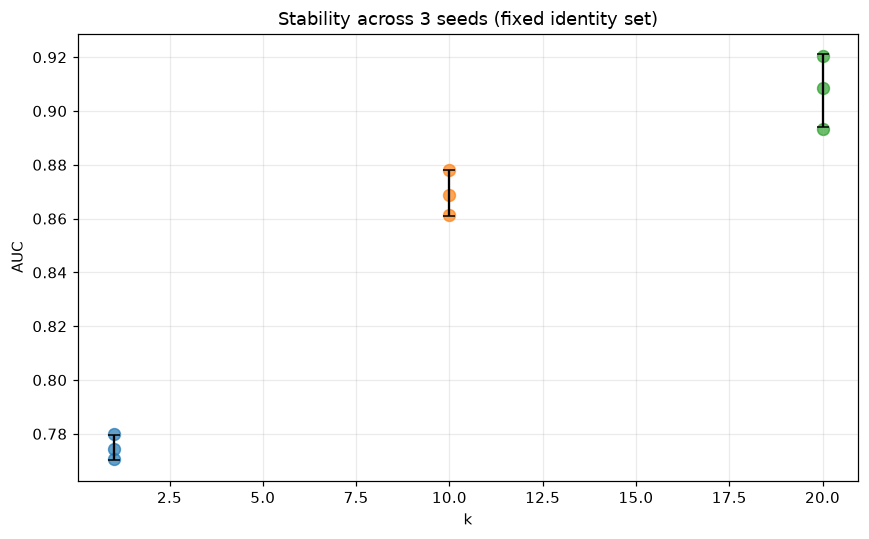

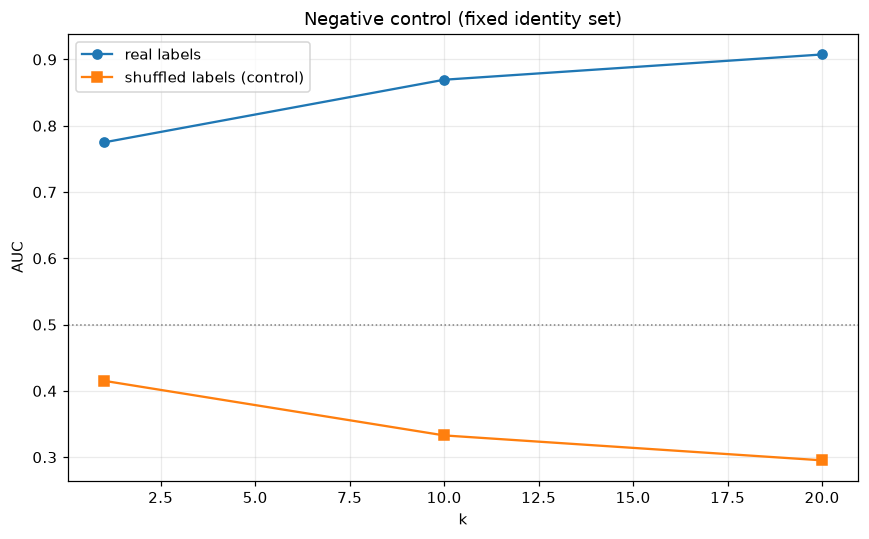

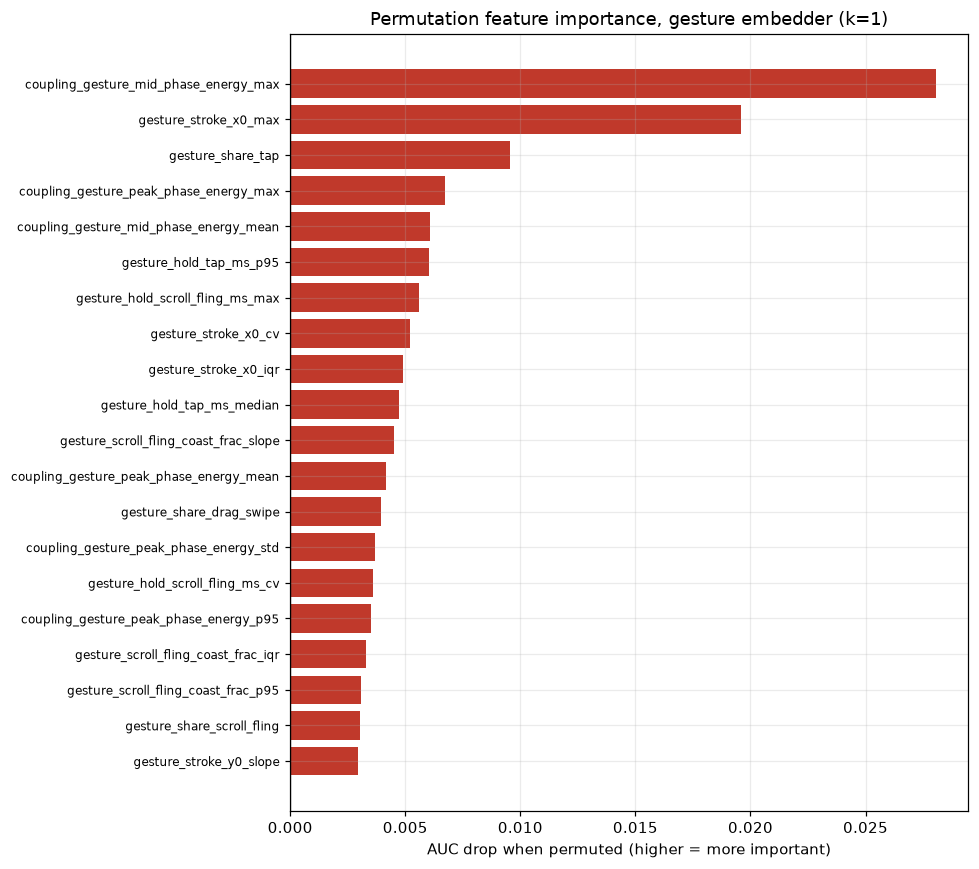

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
top = importance_df.head(20).iloc[::-1]
ax.barh(range(len(top)), top['auc_drop'], color=['#c0392b' if v > 0 else '#7f8c8d' for v in top['auc_drop']])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['feature'], fontsize=8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('AUC drop when permuted (higher = more important)')
ax.set_title('Permutation feature importance, gesture embedder (k=1)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

n_negative = (importance_df['auc_drop'] < -0.005).sum()
if n_negative:
    print(f"\nNOTE: {n_negative} feature(s) show a NEGATIVE auc_drop (performance improved when "
          f"permuted, i.e. removing their real signal helped) -- worth checking whether these are "
          f"adding noise rather than signal, candidates for exclusion in a future feature-set pass.")


## 10. Embedding space, qualitatively

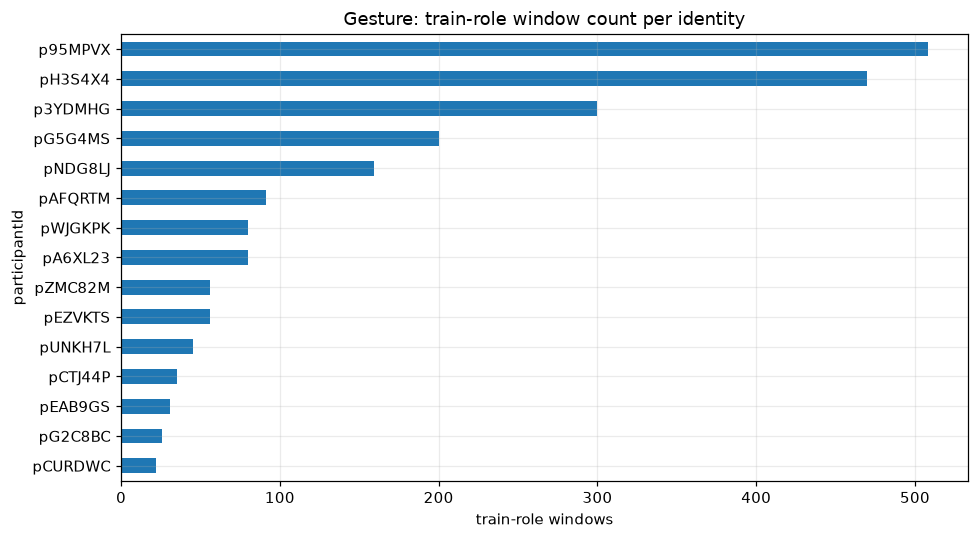

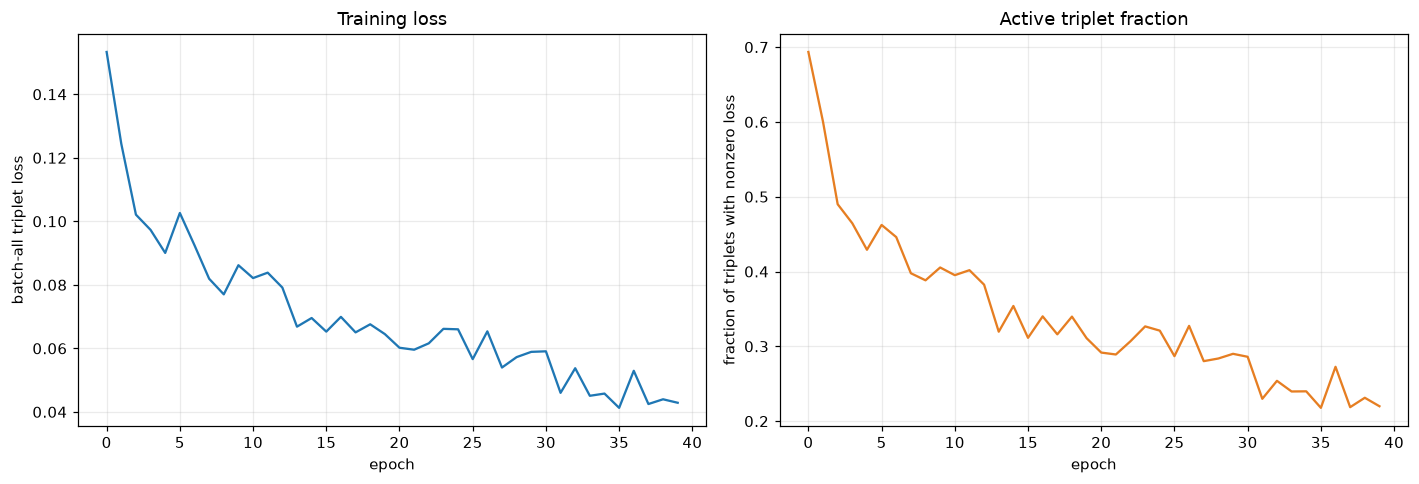

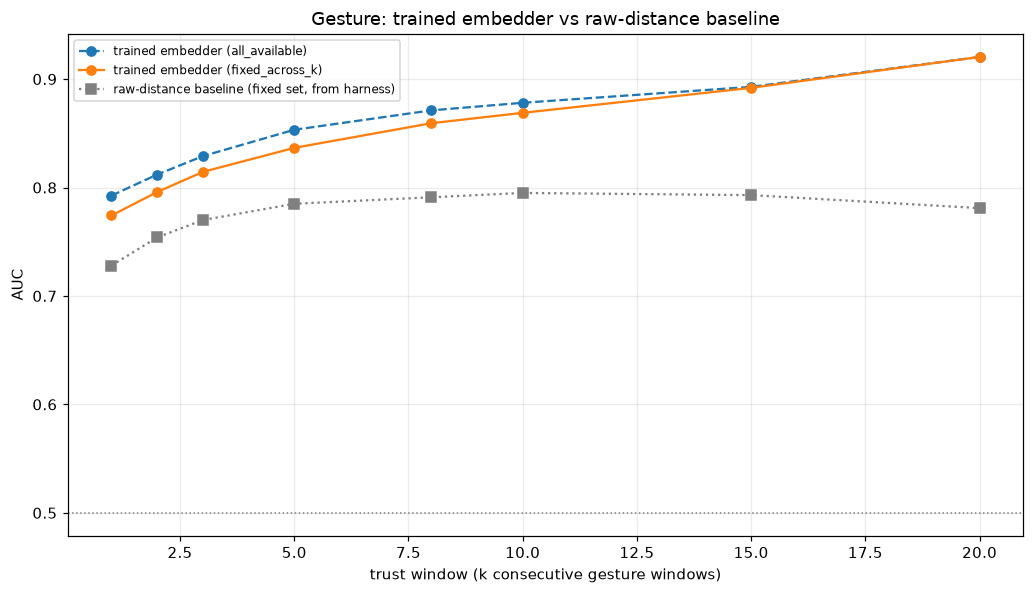

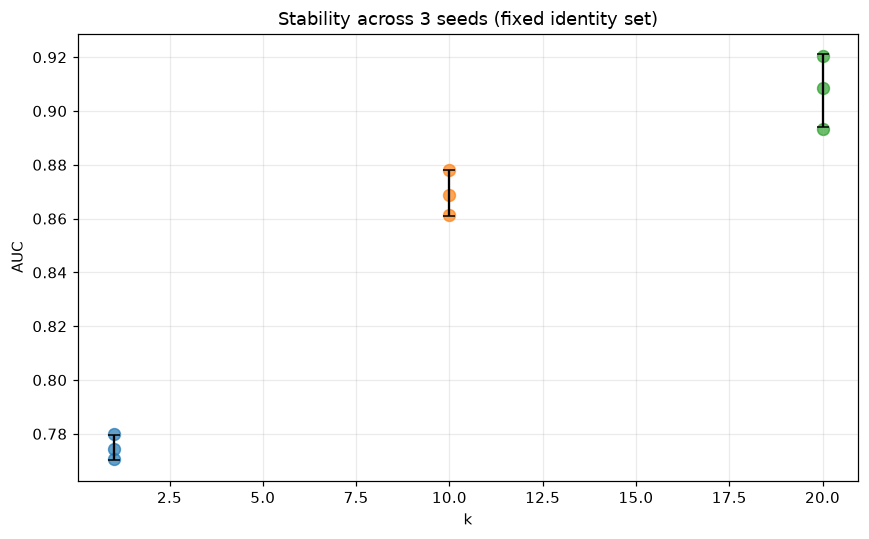

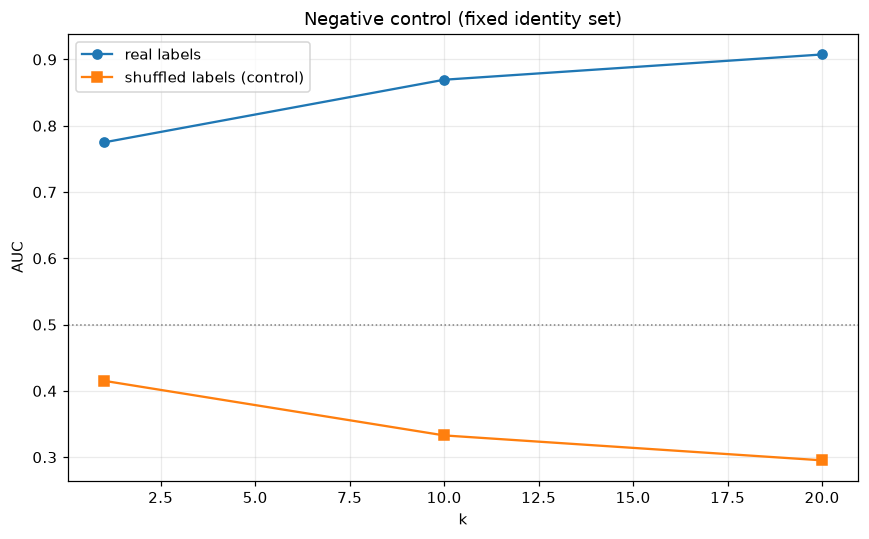

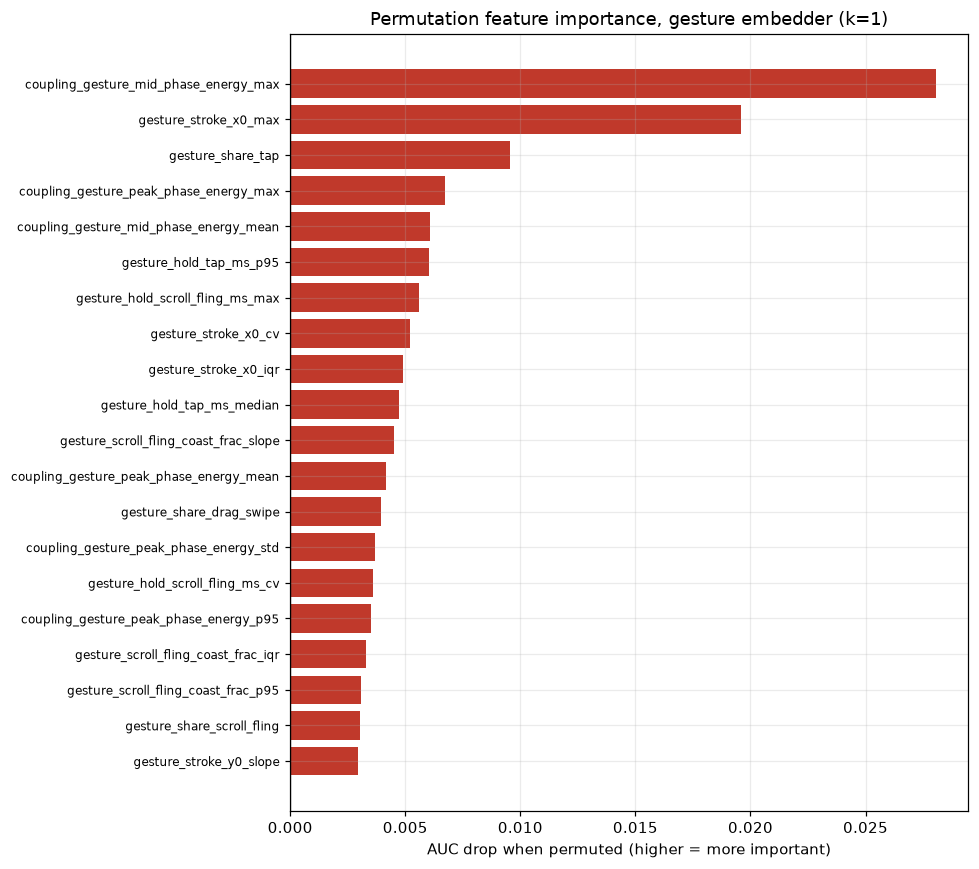

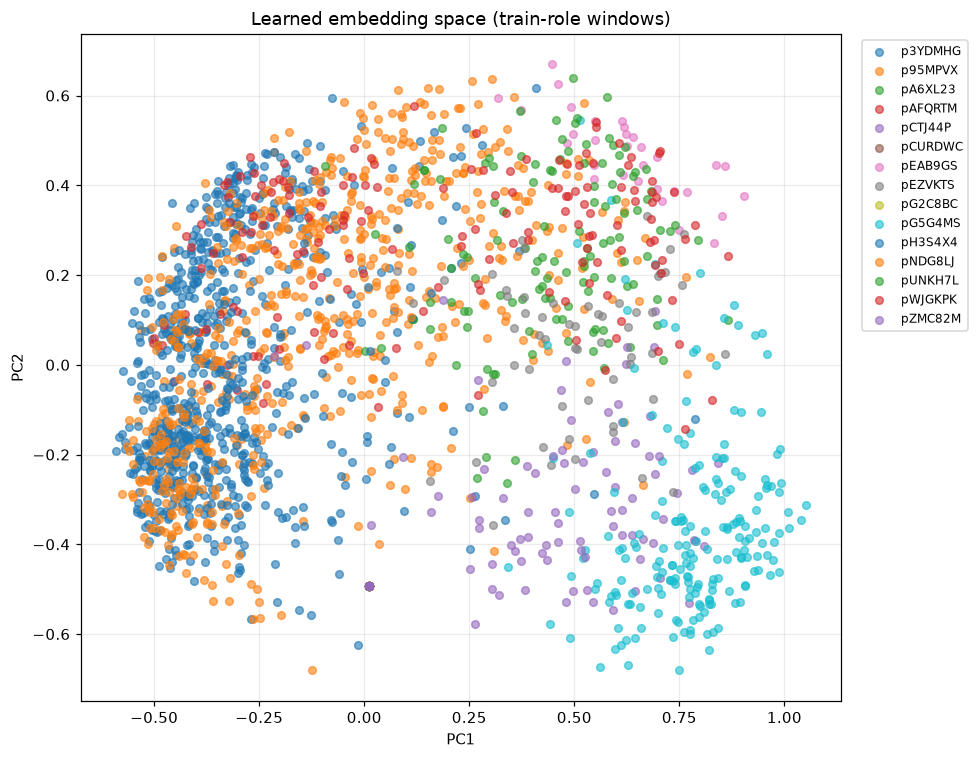

explained variance (first 2 PCs): [0.355 0.18 ]


In [15]:
with torch.no_grad():
    E_train = embed(model, X_all[role_all == 'train'])
y_train_plot = y_all[role_all == 'train']

pca = PCA(n_components=2).fit(E_train)
E2 = pca.transform(E_train)

fig, ax = plt.subplots(figsize=(9, 7))
for pid in np.unique(y_train_plot):
    m = y_train_plot == pid
    ax.scatter(E2[m, 0], E2[m, 1], label=pid, alpha=0.6, s=25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Learned embedding space (train-role windows)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '06_embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"explained variance (first 2 PCs): {pca.explained_variance_ratio_.round(3)}")


## 11. Export

In [16]:
import json
from datetime import datetime, timezone

res_df.to_csv(OUT_DIR / 'trained_vs_baseline.csv', index=False)
per_id_df.to_csv(OUT_DIR / 'per_participant.csv', index=False)
seed_df.to_csv(OUT_DIR / 'seed_stability_raw.csv', index=False)
summary.reset_index().to_csv(OUT_DIR / 'seed_stability_summary.csv', index=False)
control_df.to_csv(OUT_DIR / 'negative_control_raw.csv', index=False)
compare.reset_index().to_csv(OUT_DIR / 'negative_control_summary.csv', index=False)
history.to_csv(OUT_DIR / 'training_history_seed42.csv', index=False)
importance_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)

torch.save({'state_dict': model.state_dict(), 'feature_names': feats, 'embed_dim': EMBED_DIM},
           OUT_DIR / 'model_seed42.pt')
np.savez(OUT_DIR / 'preprocessing.npz', impute_values=imputer.statistics_,
         scale_mean=scaler.mean_, scale_scale=scaler.scale_,
         feature_names=np.array(feats, dtype=object))

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'modality': 'gesture', 'data_fingerprint': fp,
    'n_windows': int(len(df)), 'n_features': len(feats),
    'n_reference_identities': len(refs), 'n_fixed_identities': len(fixed_identities),
    'fixed_identities': sorted(fixed_identities),
    'architecture': '256-128-32 MLP, dropout 0.10, L2-normalised output',
    'max_batches_per_epoch': MAX_BATCHES_PER_EPOCH, 'epochs': EPOCHS, 'seeds_run': SEEDS,
    'auc_real_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in summary['mean'].items()},
    'auc_shuffled_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in ctrl_summary['mean'].items()},
    'files': sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()) +
             ['plots/' + p.name for p in PLOTS_DIR.iterdir()],
}
with open(OUT_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/modelling/gesture_embedder:
  checkpoints/control0_04e56bc6e42c35d2.pt  (209.6 KB)
  checkpoints/control1_04e56bc6e42c35d2.pt  (209.6 KB)
  checkpoints/control2_04e56bc6e42c35d2.pt  (209.6 KB)
  checkpoints/primary_seed42_04e56bc6e42c35d2.pt  (211.8 KB)
  checkpoints/seed13_04e56bc6e42c35d2.pt  (209.5 KB)
  checkpoints/seed42_04e56bc6e42c35d2.pt  (209.5 KB)
  checkpoints/seed7_04e56bc6e42c35d2.pt  (209.5 KB)
  feature_importance.csv  (3.0 KB)
  manifest.json  (1.3 KB)
  model_seed42.pt  (211.4 KB)
  negative_control_raw.csv  (0.8 KB)
  negative_control_summary.csv  (0.2 KB)
  per_participant.csv  (7.0 KB)
  plots/01_train_windows_per_identity.png  (53.7 KB)
  plots/02_training_curves.png  (91.0 KB)
  plots/03_embedder_vs_baseline.png  (68.3 KB)
  plots/04_seed_stability.png  (35.8 KB)
  plots/05_negative_control.png  (44.0 KB)
  plots/06_embedding_space_pca.png  (378.5 KB)
  plots/07_feature_importance.png  (102.1 

## How to avoid the wait on repeat runs

- **Don't Restart & Run All unless something upstream actually changed.**
  Once Sections 1-4 have run once, the trained model and prepared data stay
  in the kernel's memory -- editing and re-running Section 9 or 10 alone
  (Shift+Enter on just that cell, or "Run Selected Cell and All Below" from
  that point) reuses everything already computed and takes seconds, not
  minutes.
- **If you do need a fresh kernel, checkpointing now covers most of the
  cost.** `FORCE_RETRAIN = False` means Sections 4/7/8 reload the 7 trained
  models from `checkpoints/` (keyed on a fingerprint of the data, features,
  and roles) rather than retraining, as long as nothing upstream changed.
  Only a genuine change -- new data, a different feature set, a
  hyperparameter edit -- invalidates the cache and forces a real retrain.
- **`MAX_BATCHES_PER_EPOCH` (Section 3) bounds every training run
  regardless of dataset size.** Lower it (e.g. to 50) for a quick sanity
  check while iterating on unrelated cells like Section 9's plot styling;
  raise it back before a run whose numbers you intend to keep.
- **Sections 7 and 8 are the bulk of the remaining cost** (6 of the 7 total
  trainings). Comment out seeds/control indices you don't need while
  iterating on something else, and restore the full list before a final run.
